# Reconstruction historique des profils horaires de charge régionale du Sénégal (2000–2022)

## Objectif
Reconstruire des séries horaires régionales de charge électrique à partir de :

- charges observées de février 2021 à juillet 2022,
- températures horaires ERA5 de 2000 à 2024,
- consommation nationale annuelle d’électricité.

## Formulation

$$
L_{r,t}^{y} = E_{r,y}\cdot u_{r,t}^{y}
$$

avec :

- $L_{r,t}^{y}$ : charge horaire reconstruite pour la région $r$, à l’heure $t$, l’année $y$,
- $E_{r,y}$ : énergie annuelle régionale,
- $u_{r,t}^{y}$ : profil horaire normalisé.

## Principes retenus
- Les valeurs négatives de charge sont corrigées par la médiane de classe $(month, daytype, hour)$.
- Les données observées peuvent contenir des **trous temporels** ; ils sont **détectés et documentés**, mais **pas interpolés** pour l’apprentissage.
- Les profils typiques et l’estimation de $\beta_r$ sont calculés uniquement à partir des observations réellement disponibles.
- Les séries reconstruites finales sont **continues**, car elles sont générées sur l’axe temporel complet de la température ERA5.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

## Paramètres

In [9]:
BASE_DIR = Path(r"/home/ahmany/om4a/genesys-mod/GENeSYS_MOD.tools-main/GIS_&_Timeseries_Tool")

LOAD_INPUT = BASE_DIR / "consumption_hourly_2022_7regions_proxy_ZS_MW.xlsx"
LOAD_SHEET = "consumption_hourly_2022_7region"
LOAD_DATE_COL = "Date"

TEMP_INPUT = BASE_DIR / "temperature_senegal_2000_2024.xlsx"
TEMP_SHEET = "Sheet1"
TEMP_DATE_COL = "time"

ANNUAL_INPUT = BASE_DIR / "consom_elect_senegal.xlsx"
ANNUAL_SHEET = "Conso_annuelle"

T_THRESHOLD = 24.0
EPS = 1e-6
START_YEAR = 2000
END_YEAR = 2022

REGIONS = ["Dakar", "Thies", "Diourbel", "MTKK", "FKK", "LS", "ZS"]

OUT_DIR = BASE_DIR / "out_historical_reconstruction_2000_2022_v2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Fonctions utilitaires

In [10]:
def read_timeseries_excel(path, sheet_name, date_col):
    df = pd.read_excel(path, sheet_name=sheet_name)
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col]).sort_values(date_col).drop_duplicates(subset=[date_col], keep="last")
    df = df.set_index(date_col)
    df.index.name = "datetime"
    return df

def add_classes_from_index(idx: pd.DatetimeIndex) -> pd.DataFrame:
    c = pd.DataFrame(index=idx)
    c["year"] = idx.year
    c["month"] = idx.month
    c["hour"] = idx.hour
    c["weekday"] = idx.dayofweek
    c["daytype"] = np.select(
        [c["weekday"] <= 4, c["weekday"] == 5, c["weekday"] == 6],
        [0, 1, 2]
    ).astype(int)
    return c

def to_long(df_wide, value_name):
    out = df_wide.copy()
    out["datetime"] = out.index
    out = out.reset_index(drop=True).melt(
        id_vars=["datetime"],
        var_name="region",
        value_name=value_name
    )
    return out

def compute_cdd(x, threshold=24.0):
    return (x - threshold).clip(lower=0)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def safe_mape(y_true, y_pred, threshold=1.0):
    mask = y_true > threshold
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def detect_time_gaps(index, freq="h"):
    full_index = pd.date_range(index.min(), index.max(), freq=freq)
    missing = full_index.difference(index)
    return missing

def summarize_gaps(missing_index):
    if len(missing_index) == 0:
        return pd.DataFrame(columns=["gap_start", "gap_end", "n_hours"])
    gaps = []
    start = missing_index[0]
    prev = missing_index[0]
    count = 1
    for ts in missing_index[1:]:
        if ts - prev == pd.Timedelta(hours=1):
            count += 1
            prev = ts
        else:
            gaps.append({"gap_start": start, "gap_end": prev, "n_hours": count})
            start = ts
            prev = ts
            count = 1
    gaps.append({"gap_start": start, "gap_end": prev, "n_hours": count})
    return pd.DataFrame(gaps)

def class_median(series: pd.Series, classes: pd.DataFrame) -> pd.Series:
    tmp = pd.concat([series.rename("y"), classes], axis=1)
    return tmp.groupby(["month", "daytype", "hour"])["y"].median()

def replace_negatives_with_class_median(df: pd.DataFrame):
    classes = add_classes_from_index(df.index)
    df_out = df.copy()
    report_rows = []

    for col in df_out.columns:
        s = df_out[col].astype(float)
        neg_mask = s < 0
        n_neg = int(neg_mask.sum())

        if n_neg == 0:
            report_rows.append({"region": col, "n_negative": 0, "fallback_used": 0, "note": "OK"})
            continue

        s_for_median = s.mask(s < 0)
        med = class_median(s_for_median, classes)

        keys = list(zip(classes["month"], classes["daytype"], classes["hour"]))
        med_by_row = pd.Series([med.get(k, np.nan) for k in keys], index=s.index)

        global_med = float(np.nanmedian(s_for_median.values)) if np.isfinite(np.nanmedian(s_for_median.values)) else 0.0
        fill_vals = med_by_row.fillna(global_med)

        s_corrected = s.copy()
        s_corrected[neg_mask] = fill_vals[neg_mask]
        df_out[col] = s_corrected

        report_rows.append({
            "region": col,
            "n_negative": n_neg,
            "fallback_used": int(med_by_row[neg_mask].isna().sum()),
            "note": "Replaced by class median"
        })

    report = pd.DataFrame(report_rows).sort_values("n_negative", ascending=False)
    return df_out, report

def complete_864_with_neighbor(profile: pd.Series) -> pd.Series:
    full_index = pd.MultiIndex.from_product(
        [range(1, 13), [0, 1, 2], range(24)],
        names=["month", "daytype", "hour"]
    )
    prof_full = profile.reindex(full_index)

    tmp = prof_full.reset_index(name="value")
    dh_median = tmp.groupby(["daytype", "hour"])["value"].median()

    def neighbor_value(m, d, h):
        for dist in range(1, 12):
            left = m - dist
            right = m + dist
            if left >= 1:
                v = prof_full.loc[(left, d, h)]
                if pd.notna(v):
                    return v
            if right <= 12:
                v = prof_full.loc[(right, d, h)]
                if pd.notna(v):
                    return v
        return dh_median.get((d, h), np.nan)

    nan_mask = prof_full.isna()
    if nan_mask.any():
        for (m, d, h) in prof_full.index[nan_mask]:
            prof_full.loc[(m, d, h)] = neighbor_value(m, d, h)

    return prof_full

def first_contiguous_window(df_region, window_hours=24*7):
    df_region = df_region.sort_values("datetime").copy()
    dt = pd.to_datetime(df_region["datetime"])
    diffs = dt.diff().fillna(pd.Timedelta(hours=1))
    segment_id = (diffs != pd.Timedelta(hours=1)).cumsum()
    df_region["segment_id"] = segment_id.values

    segment_sizes = df_region.groupby("segment_id").size().reset_index(name="n")
    valid_segments = segment_sizes[segment_sizes["n"] >= window_hours]

    if len(valid_segments) == 0:
        return None

    seg = valid_segments.iloc[0]["segment_id"]
    return df_region[df_region["segment_id"] == seg].iloc[:window_hours].copy()

def validation_comment(corr_val, mape_val):
    if pd.notna(corr_val) and pd.notna(mape_val):
        if corr_val > 0.85 and mape_val < 0.20:
            return "Excellent"
        elif corr_val > 0.70 and mape_val < 0.25:
            return "Bon"
        elif corr_val > 0.50:
            return "Acceptable"
    return "Faible"

def validation_error_description(corr_val, mape_val, peak_err_pct):
    if pd.notna(mape_val) and mape_val > 0.30:
        return "Erreur élevée surtout sur faibles charges"
    if pd.notna(peak_err_pct) and abs(peak_err_pct) > 20:
        return "Mauvaise estimation des pics"
    if pd.notna(corr_val) and corr_val < 0.60:
        return "Dynamique temporelle partiellement capturée"
    return "Bonne reproduction globale du profil"

## Lecture des données

In [11]:
load_obs_wide = read_timeseries_excel(LOAD_INPUT, LOAD_SHEET, LOAD_DATE_COL)
temp_wide = read_timeseries_excel(TEMP_INPUT, TEMP_SHEET, TEMP_DATE_COL)
annual_nat_raw = pd.read_excel(ANNUAL_INPUT, sheet_name=ANNUAL_SHEET)

display(load_obs_wide.head())
display(temp_wide.head())
display(annual_nat_raw.head())

,Dakar,Thies,Diourbel,LS,FKK,MTKK,ZS
datetime,,,,,,,
2022-01-01 00:00:00,288.670323,82.571012,43.294951,38.800224,68.571154,49.805996,23.179077
2022-01-01 01:00:00,276.985516,78.936717,41.289875,37.050349,65.034973,46.693121,22.133710
2022-01-01 02:00:00,264.849349,75.195289,39.565683,35.415390,62.194700,46.051432,21.156993
2022-01-01 03:00:00,256.616393,73.365780,38.450791,34.281889,60.058426,47.184628,20.479845
2022-01-01 04:00:00,249.250331,72.545797,37.340221,33.696856,58.488589,46.734080,20.130349


,Diourbel,Dakar,Thies,FKK,LS,MTKK,ZS
datetime,,,,,,,
2000-01-01 00:00:00,18.650513,20.006667,18.855893,20.360183,20.364084,22.537245,21.374422
2000-01-01 01:00:00,18.646667,20.016667,18.934107,20.173354,20.269329,22.249886,21.386149
2000-01-01 02:00:00,17.554103,19.700000,18.351786,19.226353,18.997972,21.597183,21.118602
2000-01-01 03:00:00,16.647949,19.516667,17.974464,18.065180,17.952504,20.333894,20.222340
2000-01-01 04:00:00,16.605897,19.586667,18.025714,17.870204,17.870643,20.370845,20.058458


,country,year,fuel,value(GWh)
0,SN,2023,Power,7547.0
1,SN,2022,Power,7001.0
2,SN,2021,Power,5955.0
3,SN,2020,Power,5506.9
4,SN,2019,Power,5330.1


## Harmonisation des régions

In [12]:
common_regions = [r for r in REGIONS if r in load_obs_wide.columns and r in temp_wide.columns]
print("Régions communes :", common_regions)

load_obs_wide = load_obs_wide[common_regions].copy()
temp_wide = temp_wide[common_regions].copy()

Régions communes : ['Dakar', 'Thies', 'Diourbel', 'MTKK', 'FKK', 'LS', 'ZS']


## Contrôles de qualité des données observées

In [13]:
print("Période charge observée :", load_obs_wide.index.min(), "->", load_obs_wide.index.max())
print("Période température    :", temp_wide.index.min(), "->", temp_wide.index.max())
print("Shape charge:", load_obs_wide.shape)
print("Shape temp  :", temp_wide.shape)

missing_load = detect_time_gaps(load_obs_wide.index)
gap_summary = summarize_gaps(missing_load)

print("Nombre de timestamps manquants dans la charge :", len(missing_load))
display(gap_summary.head(20))

Période charge observée : 2022-01-01 00:00:00 -> 2022-12-31 23:00:00
Période température    : 2000-01-01 00:00:00 -> 2024-12-31 23:00:00
Shape charge: (8760, 7)
Shape temp  : (219168, 7)
Nombre de timestamps manquants dans la charge : 0


,gap_start,gap_end,n_hours


## Correction des valeurs négatives de charge

In [14]:
load_obs_wide, neg_report = replace_negatives_with_class_median(load_obs_wide)
display(neg_report)
print("Négatifs restants :", int((load_obs_wide < 0).sum().sum()))

,region,n_negative,fallback_used,note
0,Dakar,0,0,OK
1,Thies,0,0,OK
2,Diourbel,0,0,OK
3,MTKK,0,0,OK
4,FKK,0,0,OK
5,LS,0,0,OK
6,ZS,0,0,OK


Négatifs restants : 0


## Passage au format long et ajout des classes temporelles

In [15]:
load_obs = to_long(load_obs_wide, "load_mw")
temp_long = to_long(temp_wide, "temp_c")

load_obs = pd.concat(
    [load_obs.reset_index(drop=True),
     add_classes_from_index(pd.DatetimeIndex(load_obs["datetime"])).reset_index(drop=True)],
    axis=1
)

temp_long = pd.concat(
    [temp_long.reset_index(drop=True),
     add_classes_from_index(pd.DatetimeIndex(temp_long["datetime"])).reset_index(drop=True)],
    axis=1
)

display(load_obs.head())
display(temp_long.head())

,datetime,region,load_mw,year,month,hour,weekday,daytype
0,2022-01-01 00:00:00,Dakar,288.670323,2022,1,0,5,1
1,2022-01-01 01:00:00,Dakar,276.985516,2022,1,1,5,1
2,2022-01-01 02:00:00,Dakar,264.849349,2022,1,2,5,1
3,2022-01-01 03:00:00,Dakar,256.616393,2022,1,3,5,1
4,2022-01-01 04:00:00,Dakar,249.250331,2022,1,4,5,1


,datetime,region,temp_c,year,month,hour,weekday,daytype
0,2000-01-01 00:00:00,Dakar,20.006667,2000,1,0,5,1
1,2000-01-01 01:00:00,Dakar,20.016667,2000,1,1,5,1
2,2000-01-01 02:00:00,Dakar,19.700000,2000,1,2,5,1
3,2000-01-01 03:00:00,Dakar,19.516667,2000,1,3,5,1
4,2000-01-01 04:00:00,Dakar,19.586667,2000,1,4,5,1


## Calcul du CDD historique

$$
CDD_t = \max(T_t - T_{\mathrm{seuil}}, 0)
$$

In [16]:
temp_long["cdd_hist"] = compute_cdd(temp_long["temp_c"], threshold=T_THRESHOLD)
display(temp_long.head())
print(temp_long["cdd_hist"].describe())

,datetime,region,temp_c,year,month,hour,weekday,daytype,cdd_hist
0,2000-01-01 00:00:00,Dakar,20.006667,2000,1,0,5,1,0.0
1,2000-01-01 01:00:00,Dakar,20.016667,2000,1,1,5,1,0.0
2,2000-01-01 02:00:00,Dakar,19.700000,2000,1,2,5,1,0.0
3,2000-01-01 03:00:00,Dakar,19.516667,2000,1,3,5,1,0.0
4,2000-01-01 04:00:00,Dakar,19.586667,2000,1,4,5,1,0.0


count    1.534176e+06
mean     4.081553e+00
std      4.098497e+00
min      0.000000e+00
25%      6.573625e-02
50%      2.906667e+00
75%      6.814852e+00
max      2.140101e+01
Name: cdd_hist, dtype: float64


## Climatologie thermique de référence (2000–2024)

In [18]:
temp_clim = (
    temp_long
    .groupby(["region", "month", "daytype", "hour"], as_index=False)["temp_c"]
    .median()
    .rename(columns={"temp_c": "temp_ref_c"})
)

temp_clim["cdd_ref"] = compute_cdd(temp_clim["temp_ref_c"], threshold=T_THRESHOLD)

display(temp_clim.head())
print("Nombre de lignes climatologie :", temp_clim.shape[0])

,region,month,daytype,hour,temp_ref_c,cdd_ref
0,Dakar,1,0,0,20.973333,0.0
1,Dakar,1,0,1,20.941667,0.0
2,Dakar,1,0,2,20.670000,0.0
3,Dakar,1,0,3,20.458333,0.0
4,Dakar,1,0,4,20.391667,0.0


Nombre de lignes climatologie : 6048


## Charge typique observée par classe

In [19]:
load_typical_raw = (
    load_obs
    .groupby(["region", "month", "daytype", "hour"])["load_mw"]
    .median()
)

profiles_completed = []
for region in common_regions:
    prof_r = load_typical_raw.loc[region]
    prof_r.index = pd.MultiIndex.from_tuples(prof_r.index, names=["month", "daytype", "hour"])
    prof_r_completed = complete_864_with_neighbor(prof_r)

    df_r = prof_r_completed.reset_index(name="load_typ_mw")
    df_r["region"] = region
    profiles_completed.append(df_r)

load_typical = pd.concat(profiles_completed, ignore_index=True)[["region", "month", "daytype", "hour", "load_typ_mw"]]

display(load_typical.head())
print("Nombre de lignes charge typique :", load_typical.shape[0])

,region,month,daytype,hour,load_typ_mw
0,Dakar,1,0,0,292.322721
1,Dakar,1,0,1,274.115710
2,Dakar,1,0,2,266.857849
3,Dakar,1,0,3,260.966971
4,Dakar,1,0,4,250.659280


Nombre de lignes charge typique : 6048


## Vérification du nombre de classes par région

In [20]:
expected_classes = 12 * 3 * 24

check_classes = (
    load_typical.groupby("region")
    .size()
    .reset_index(name="n_classes")
)

print("Classes attendues :", expected_classes)
display(check_classes)

Classes attendues : 864


,region,n_classes
0,Dakar,864
1,Diourbel,864
2,FKK,864
3,LS,864
4,MTKK,864
5,Thies,864
6,ZS,864


## CDD typique observé par classe sur la période de charge

In [21]:
obs_start = load_obs["datetime"].min()
obs_end = load_obs["datetime"].max()

cdd_typical = (
    temp_long[temp_long["datetime"].between(obs_start, obs_end)]
    .groupby(["region", "month", "daytype", "hour"], as_index=False)["cdd_hist"]
    .median()
    .rename(columns={"cdd_hist": "cdd_typ"})
)

display(cdd_typical.head())
print("Nombre de lignes CDD typique :", cdd_typical.shape[0])

,region,month,daytype,hour,cdd_typ
0,Dakar,1,0,0,0.0
1,Dakar,1,0,1,0.0
2,Dakar,1,0,2,0.0
3,Dakar,1,0,3,0.0
4,Dakar,1,0,4,0.0


Nombre de lignes CDD typique : 6048


## Estimation de la sensibilité thermique

$$
\Delta L_{r,t} = \beta_r \cdot \Delta CDD_{r,t} + \epsilon_{r,t}
$$

In [22]:
obs_for_beta = (
    load_obs
    .merge(temp_long[["datetime", "region", "cdd_hist"]], on=["datetime", "region"], how="left")
    .merge(load_typical, on=["region", "month", "daytype", "hour"], how="left")
    .merge(cdd_typical, on=["region", "month", "daytype", "hour"], how="left")
)

obs_for_beta["delta_load"] = obs_for_beta["load_mw"] - obs_for_beta["load_typ_mw"]
obs_for_beta["delta_cdd"] = obs_for_beta["cdd_hist"] - obs_for_beta["cdd_typ"]

display(obs_for_beta.head())

,datetime,region,load_mw,year,month,hour,weekday,daytype,cdd_hist,load_typ_mw,cdd_typ,delta_load,delta_cdd
0,2022-01-01 00:00:00,Dakar,288.670323,2022,1,0,5,1,0.0,288.670323,0.0,0.0,0.0
1,2022-01-01 01:00:00,Dakar,276.985516,2022,1,1,5,1,0.0,276.985516,0.0,0.0,0.0
2,2022-01-01 02:00:00,Dakar,264.849349,2022,1,2,5,1,0.0,264.849349,0.0,0.0,0.0
3,2022-01-01 03:00:00,Dakar,256.616393,2022,1,3,5,1,0.0,256.616393,0.0,0.0,0.0
4,2022-01-01 04:00:00,Dakar,249.250331,2022,1,4,5,1,0.0,249.250331,0.0,0.0,0.0


In [23]:
beta_rows = []

for region in common_regions:
    df_r = obs_for_beta.loc[
        obs_for_beta["region"] == region,
        ["delta_load", "delta_cdd"]
    ].dropna()

    X = df_r[["delta_cdd"]].values
    y = df_r["delta_load"].values

    model = LinearRegression(fit_intercept=True)
    model.fit(X, y)

    beta_raw = float(model.coef_[0])
    intercept = float(model.intercept_)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    beta_corrected = max(beta_raw, 0.0)
    if r2 < 0.01:
        beta_corrected = 0.0

    beta_rows.append({
        "region": region,
        "beta_raw": beta_raw,
        "beta_MW_per_degC": beta_corrected,
        "intercept": intercept,
        "r2": r2,
        "n_obs": len(df_r)
    })

beta_df = pd.DataFrame(beta_rows).sort_values("region")
display(beta_df)

BETA_MAP = dict(zip(beta_df["region"], beta_df["beta_MW_per_degC"]))
print(BETA_MAP)

,region,beta_raw,beta_MW_per_degC,intercept,r2,n_obs
0,Dakar,3.938187,3.938187,-3.177047,0.026735,8760
2,Diourbel,0.727868,0.727868,0.289091,0.060341,8760
4,FKK,1.036057,1.036057,-0.584423,0.052145,8760
5,LS,0.315735,0.315735,-0.019927,0.016347,8760
3,MTKK,0.460820,0.000000,-0.643599,0.005290,8760
1,Thies,0.915080,0.915080,-0.040973,0.036204,8760
6,ZS,0.157379,0.000000,-0.015219,0.006339,8760


{'Dakar': 3.9381872273259577, 'Diourbel': 0.7278684045643661, 'FKK': 1.036056614148486, 'LS': 0.31573472333011565, 'MTKK': 0.0, 'Thies': 0.9150804373984024, 'ZS': 0.0}


## Visualisation rapide des régressions

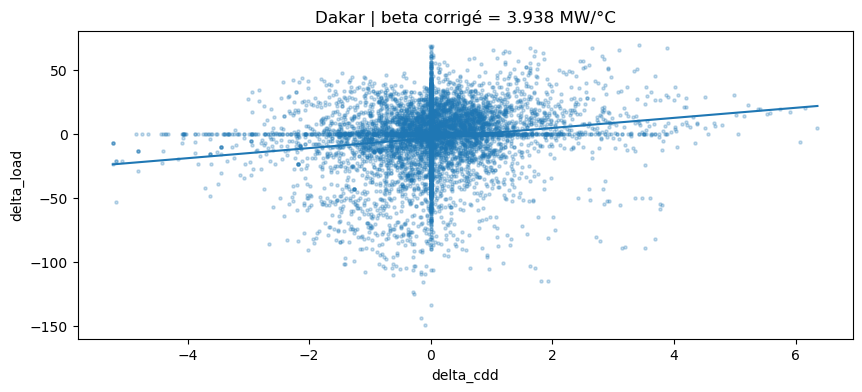

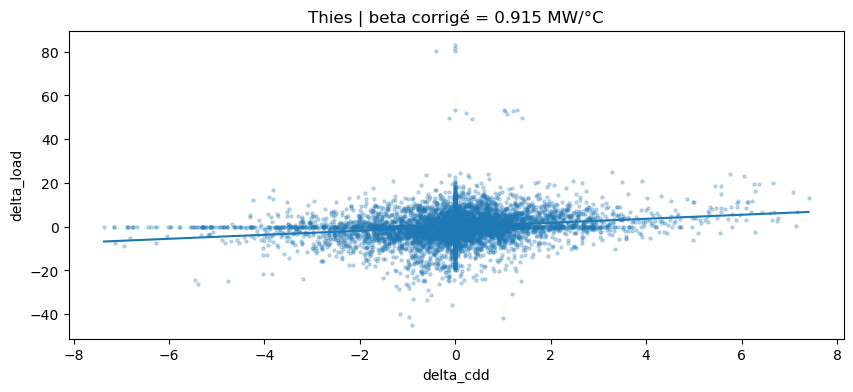

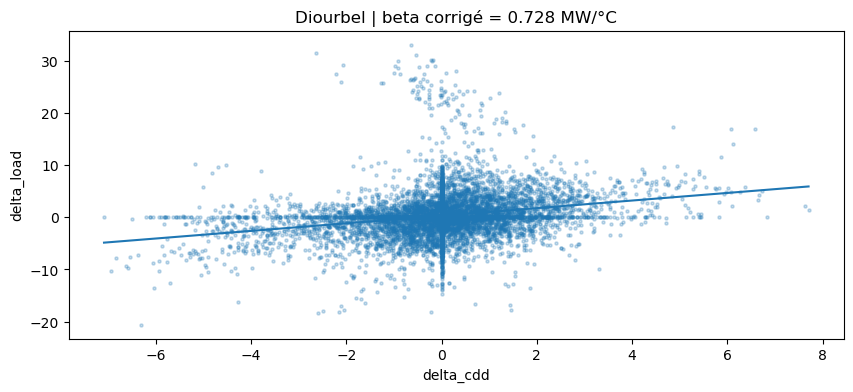

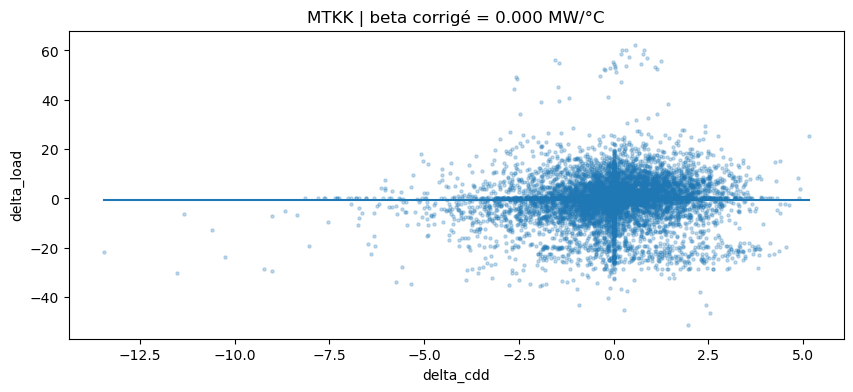

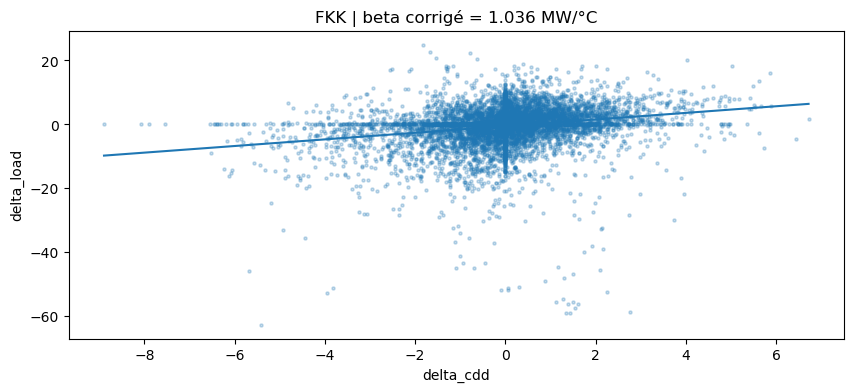

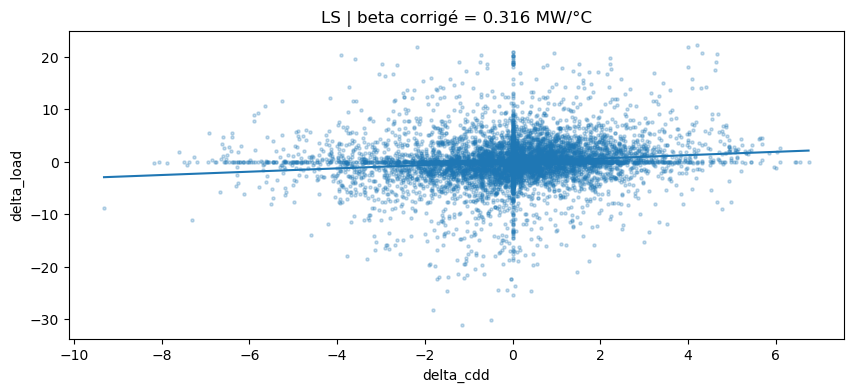

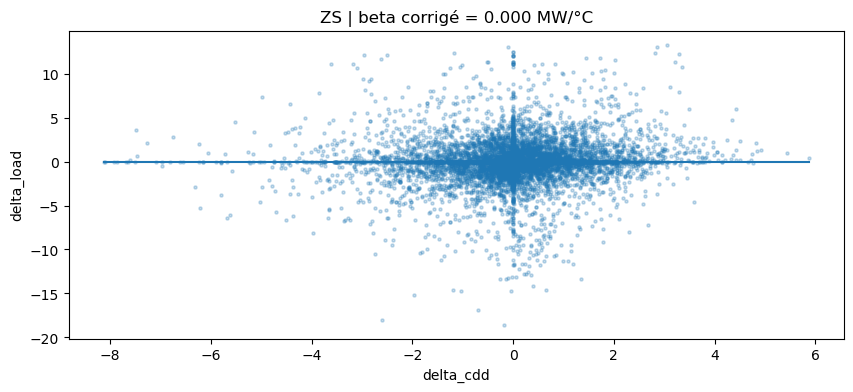

In [24]:
for region in common_regions:
    df_r = obs_for_beta.loc[obs_for_beta["region"] == region].dropna(subset=["delta_cdd", "delta_load"])

    plt.figure()
    plt.scatter(df_r["delta_cdd"], df_r["delta_load"], s=5, alpha=0.25)

    beta = beta_df.loc[beta_df["region"] == region, "beta_MW_per_degC"].iloc[0]
    intercept = beta_df.loc[beta_df["region"] == region, "intercept"].iloc[0]

    xline = np.linspace(df_r["delta_cdd"].min(), df_r["delta_cdd"].max(), 100)
    yline = intercept + beta * xline
    plt.plot(xline, yline)

    plt.title(f"{region} | beta corrigé = {beta:.3f} MW/°C")
    plt.xlabel("delta_cdd")
    plt.ylabel("delta_load")
    plt.show()

## Profil de référence par classe

In [25]:
load_ref_class = load_typical.merge(
    temp_clim[["region", "month", "daytype", "hour", "cdd_ref"]],
    on=["region", "month", "daytype", "hour"],
    how="left"
).rename(columns={"load_typ_mw": "load_ref_mw"})

display(load_ref_class.head())

,region,month,daytype,hour,load_ref_mw,cdd_ref
0,Dakar,1,0,0,292.322721,0.0
1,Dakar,1,0,1,274.115710,0.0
2,Dakar,1,0,2,266.857849,0.0
3,Dakar,1,0,3,260.966971,0.0
4,Dakar,1,0,4,250.659280,0.0


## Parts régionales observées

$$
s_r = \frac{\sum_t L_{r,t}}{\sum_r \sum_t L_{r,t}}
$$

In [26]:
regional_shares = (
    load_obs.groupby("region", as_index=False)["load_mw"].sum()
    .rename(columns={"load_mw": "observed_energy_proxy"})
)

regional_shares["share"] = regional_shares["observed_energy_proxy"] / regional_shares["observed_energy_proxy"].sum()
display(regional_shares)
print("Somme des parts =", regional_shares["share"].sum())

,region,observed_energy_proxy,share
0,Dakar,2.953543e+06,0.508610
1,Diourbel,3.922711e+05,0.067550
2,FKK,6.093721e+05,0.104936
3,LS,3.711215e+05,0.063908
4,MTKK,5.108999e+05,0.087979
5,Thies,7.481718e+05,0.128838
6,ZS,2.217063e+05,0.038179


Somme des parts = 1.0000000000000002


## Préparation de la consommation nationale annuelle (2000–2022)

In [27]:
annual_nat = annual_nat_raw.copy()

annual_nat = annual_nat[annual_nat["country"] == "SN"].copy()
annual_nat = annual_nat[annual_nat["fuel"].str.lower() == "power"].copy()

annual_nat["energy_nat_mwh"] = annual_nat["value(GWh)"] * 1000.0

annual_nat = annual_nat[["year", "energy_nat_mwh"]].copy()
annual_nat = annual_nat[(annual_nat["year"] >= START_YEAR) & (annual_nat["year"] <= END_YEAR)].sort_values("year")

display(annual_nat.head())
display(annual_nat.tail())
print("Années disponibles fichier annuel :", sorted(annual_nat["year"].unique()))

,year,energy_nat_mwh
23,2000,898000.0
22,2001,1153800.0
21,2002,1557000.0
20,2003,1534000.0
19,2004,1647000.0


,year,energy_nat_mwh
5,2018,4590400.0
4,2019,5330100.0
3,2020,5506900.0
2,2021,5955000.0
1,2022,7001000.0


Années disponibles fichier annuel : [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


## Ajustement météo

$$
\tilde{L}_{r,t}^{y}
=
L_{r,m,d,h}^{\mathrm{ref}}
+
\beta_r \left(
CDD_{r,t}^{\mathrm{hist}} - CDD_{r,m,d,h}^{\mathrm{ref}}
\right)
$$

In [28]:
temp_hist = temp_long.merge(
    temp_clim[["region", "month", "daytype", "hour", "cdd_ref"]],
    on=["region", "month", "daytype", "hour"],
    how="left"
).merge(
    load_ref_class[["region", "month", "daytype", "hour", "load_ref_mw"]],
    on=["region", "month", "daytype", "hour"],
    how="left"
)

temp_hist["beta"] = temp_hist["region"].map(BETA_MAP)

temp_hist["load_weather_adj_mw"] = (
    temp_hist["load_ref_mw"] +
    temp_hist["beta"] * (temp_hist["cdd_hist"] - temp_hist["cdd_ref"])
)

temp_hist["load_weather_adj_mw"] = temp_hist["load_weather_adj_mw"].clip(lower=EPS)
display(temp_hist.head())

,datetime,region,temp_c,year,month,hour,weekday,daytype,cdd_hist,cdd_ref,load_ref_mw,beta,load_weather_adj_mw
0,2000-01-01 00:00:00,Dakar,20.006667,2000,1,0,5,1,0.0,0.0,288.670323,3.938187,288.670323
1,2000-01-01 01:00:00,Dakar,20.016667,2000,1,1,5,1,0.0,0.0,276.985516,3.938187,276.985516
2,2000-01-01 02:00:00,Dakar,19.700000,2000,1,2,5,1,0.0,0.0,264.849349,3.938187,264.849349
3,2000-01-01 03:00:00,Dakar,19.516667,2000,1,3,5,1,0.0,0.0,256.616393,3.938187,256.616393
4,2000-01-01 04:00:00,Dakar,19.586667,2000,1,4,5,1,0.0,0.0,249.250331,3.938187,249.250331


## Normalisation annuelle

$$
u_{r,t}^{y}
=
\frac{\max\left(\tilde{L}_{r,t}^{y}, \epsilon\right)}
{\sum_{t \in y} \max\left(\tilde{L}_{r,t}^{y}, \epsilon\right)}
$$

In [29]:
temp_hist["year"] = pd.to_datetime(temp_hist["datetime"]).dt.year

sum_by_region_year = temp_hist.groupby(["region", "year"])["load_weather_adj_mw"].transform("sum")
temp_hist["u"] = temp_hist["load_weather_adj_mw"] / sum_by_region_year

check_sum = temp_hist.groupby(["region", "year"], as_index=False)["u"].sum()
display(check_sum.head(20))

,region,year,u
0,Dakar,2000,1.0
1,Dakar,2001,1.0
2,Dakar,2002,1.0
3,Dakar,2003,1.0
4,Dakar,2004,1.0
5,Dakar,2005,1.0
6,Dakar,2006,1.0
7,Dakar,2007,1.0
8,Dakar,2008,1.0
9,Dakar,2009,1.0


## Allocation régionale de l’énergie annuelle

$$
E_{r,y} = s_r \cdot E_{y}^{\mathrm{nat}}
$$

In [30]:
annual_regional = annual_nat.merge(
    regional_shares[["region", "share"]],
    how="cross"
)

annual_regional["energy_regional_mwh"] = annual_regional["energy_nat_mwh"] * annual_regional["share"]
display(annual_regional.head(20))

,year,energy_nat_mwh,region,share,energy_regional_mwh
0,2000,898000.0,Dakar,0.508610,456731.927691
1,2000,898000.0,Diourbel,0.067550,60660.291266
2,2000,898000.0,FKK,0.104936,94232.489694
3,2000,898000.0,LS,0.063908,57389.741569
4,2000,898000.0,MTKK,0.087979,79004.881748
5,2000,898000.0,Thies,0.128838,115696.297499
6,2000,898000.0,ZS,0.038179,34284.370534
7,2001,1153800.0,Dakar,0.508610,586834.407761
8,2001,1153800.0,Diourbel,0.067550,77939.692720
9,2001,1153800.0,FKK,0.104936,121075.107582


## Reconstruction finale

$$
L_{r,t}^{y} = E_{r,y}\cdot u_{r,t}^{y}
$$

In [31]:
reconstructed = temp_hist.merge(
    annual_regional[["year", "region", "energy_regional_mwh"]],
    on=["year", "region"],
    how="inner"
)

reconstructed["load_reconstructed_mw"] = reconstructed["energy_regional_mwh"] * reconstructed["u"]
display(reconstructed.head())
display(reconstructed["load_reconstructed_mw"].describe())

,datetime,region,temp_c,year,month,hour,weekday,daytype,cdd_hist,cdd_ref,load_ref_mw,beta,load_weather_adj_mw,u,energy_regional_mwh,load_reconstructed_mw
0,2000-01-01 00:00:00,Dakar,20.006667,2000,1,0,5,1,0.0,0.0,288.670323,3.938187,288.670323,0.000097,456731.927691,44.188790
1,2000-01-01 01:00:00,Dakar,20.016667,2000,1,1,5,1,0.0,0.0,276.985516,3.938187,276.985516,0.000093,456731.927691,42.400115
2,2000-01-01 02:00:00,Dakar,19.700000,2000,1,2,5,1,0.0,0.0,264.849349,3.938187,264.849349,0.000089,456731.927691,40.542347
3,2000-01-01 03:00:00,Dakar,19.516667,2000,1,3,5,1,0.0,0.0,256.616393,3.938187,256.616393,0.000086,456731.927691,39.282070
4,2000-01-01 04:00:00,Dakar,19.586667,2000,1,4,5,1,0.0,0.0,249.250331,3.938187,249.250331,0.000084,456731.927691,38.154496


count    1.411368e+06
mean     5.391167e+01
std      7.070946e+01
min      2.756255e+00
25%      1.705090e+01
50%      3.006000e+01
75%      5.455297e+01
max      5.445651e+02
Name: load_reconstructed_mw, dtype: float64

## Contrôles de cohérence

In [32]:
annual_check = reconstructed.groupby(["year", "region"], as_index=False)["load_reconstructed_mw"].sum()

annual_check = annual_check.merge(
    annual_regional[["year", "region", "energy_regional_mwh"]],
    on=["year", "region"],
    how="left"
)

annual_check["diff_mwh"] = annual_check["load_reconstructed_mw"] - annual_check["energy_regional_mwh"]
display(annual_check.head(20))
print("Diff max absolue :", annual_check["diff_mwh"].abs().max())

cont_checks = []
for region in common_regions:
    dt = reconstructed.loc[reconstructed["region"] == region, "datetime"].sort_values()
    ok = dt.diff().dropna().eq(pd.Timedelta(hours=1)).all()
    cont_checks.append({"region": region, "continuous_hourly_series": ok})
display(pd.DataFrame(cont_checks))
print("Années reconstruites :", sorted(reconstructed["year"].dropna().unique()))

,year,region,load_reconstructed_mw,energy_regional_mwh,diff_mwh
0,2000,Dakar,456731.927691,456731.927691,0.000000e+00
1,2000,Diourbel,60660.291266,60660.291266,0.000000e+00
2,2000,FKK,94232.489694,94232.489694,1.455192e-11
3,2000,LS,57389.741569,57389.741569,0.000000e+00
4,2000,MTKK,79004.881748,79004.881748,0.000000e+00
5,2000,Thies,115696.297499,115696.297499,0.000000e+00
6,2000,ZS,34284.370534,34284.370534,0.000000e+00
7,2001,Dakar,586834.407761,586834.407761,0.000000e+00
8,2001,Diourbel,77939.692720,77939.692720,0.000000e+00
9,2001,FKK,121075.107582,121075.107582,1.455192e-11


Diff max absolue : 2.3283064365386963e-10


,region,continuous_hourly_series
0,Dakar,True
1,Thies,True
2,Diourbel,True
3,MTKK,True
4,FKK,True
5,LS,True
6,ZS,True


Années reconstruites : [np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]


## Validation sur la période observée 2021–2022

In [33]:
recon_obs_period = reconstructed[
    reconstructed["datetime"].between(obs_start, obs_end)
].copy()

validation_df = load_obs.merge(
    recon_obs_period[["datetime", "region", "load_reconstructed_mw"]],
    on=["datetime", "region"],
    how="inner"
)

display(validation_df.head())

print("Années dans validation :", sorted(validation_df["datetime"].dt.year.unique()))
missing_validation_years = sorted(set(load_obs["year"].unique()) - set(validation_df["datetime"].dt.year.unique()))
print("Années observées non validées :", missing_validation_years)
print("La validation n'utilise que les heures réellement observées ; les trous ne sont donc pas comparés.")

,datetime,region,load_mw,year,month,hour,weekday,daytype,load_reconstructed_mw
0,2022-01-01 00:00:00,Dakar,288.670323,2022,1,0,5,1,344.009529
1,2022-01-01 01:00:00,Dakar,276.985516,2022,1,1,5,1,330.084700
2,2022-01-01 02:00:00,Dakar,264.849349,2022,1,2,5,1,315.621983
3,2022-01-01 03:00:00,Dakar,256.616393,2022,1,3,5,1,305.810738
4,2022-01-01 04:00:00,Dakar,249.250331,2022,1,4,5,1,297.032575


Années dans validation : [np.int32(2022)]
Années observées non validées : []
La validation n'utilise que les heures réellement observées ; les trous ne sont donc pas comparés.


In [34]:
val_rows = []

for region in common_regions:
    df_r = validation_df[validation_df["region"] == region].dropna(
        subset=["load_mw", "load_reconstructed_mw"]
    )
    if len(df_r) == 0:
        continue

    y_true = df_r["load_mw"].values
    y_pred = df_r["load_reconstructed_mw"].values

    peak_true = y_true.max()
    peak_pred = y_pred.max()
    peak_err_pct = 100 * (peak_pred - peak_true) / peak_true if peak_true != 0 else np.nan

    rmse_val = rmse(y_true, y_pred)
    mape_val = safe_mape(y_true, y_pred, threshold=1.0)
    corr_val = np.corrcoef(y_true, y_pred)[0, 1]

    val_rows.append({
        "region": region,
        "RMSE": rmse_val,
        "MAPE": mape_val,
        "corr": corr_val,
        "peak_error_pct": peak_err_pct,
        "n_obs": len(df_r),
        "comment": validation_comment(corr_val, mape_val),
        "error_description": validation_error_description(corr_val, mape_val, peak_err_pct)
    })

validation_metrics = pd.DataFrame(val_rows).sort_values("region")
display(validation_metrics)

,region,RMSE,MAPE,corr,peak_error_pct,n_obs,comment,error_description
0,Dakar,74.687893,0.210756,0.922733,9.779123,8760,Bon,Bonne reproduction globale du profil
2,Diourbel,10.297694,0.220078,0.842953,-8.492853,8760,Bon,Bonne reproduction globale du profil
4,FKK,15.805116,0.225000,0.837902,11.416195,8760,Bon,Bonne reproduction globale du profil
5,LS,9.731064,0.223389,0.727541,-0.082448,8760,Bon,Bonne reproduction globale du profil
3,MTKK,15.479131,0.273541,0.742301,-12.835080,8760,Acceptable,Bonne reproduction globale du profil
1,Thies,18.912721,0.212553,0.849892,-9.563847,8760,Bon,Bonne reproduction globale du profil
6,ZS,5.822307,0.223571,0.722670,-0.054450,8760,Bon,Bonne reproduction globale du profil


## Graphiques de validation (fenêtre contiguë sans trou)

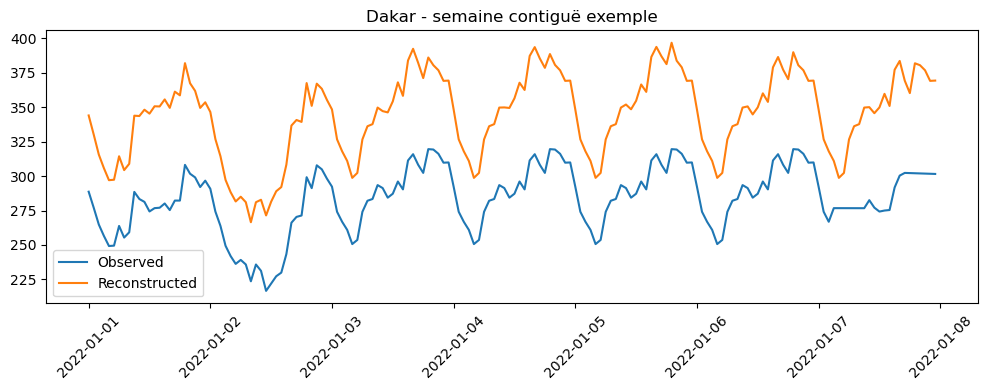

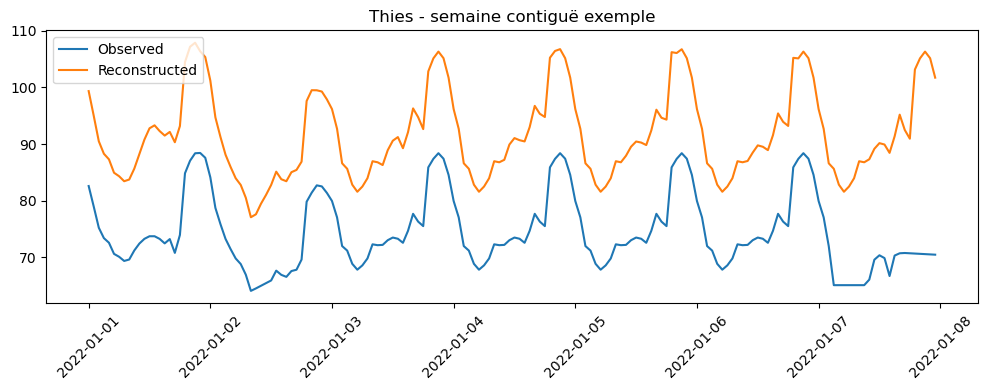

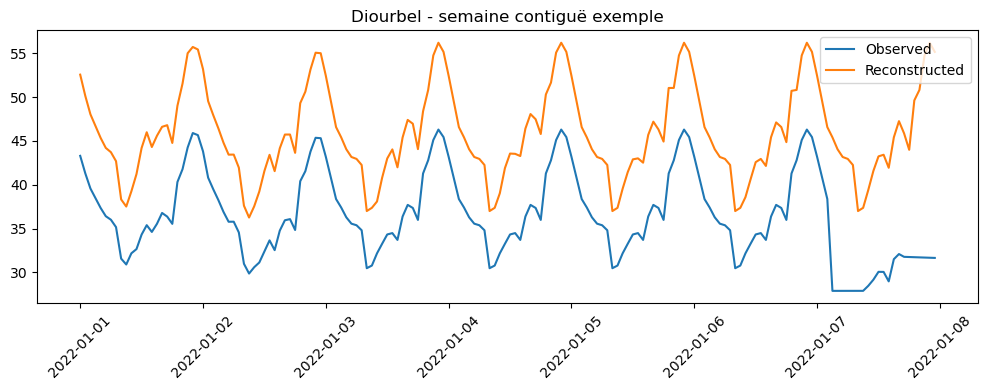

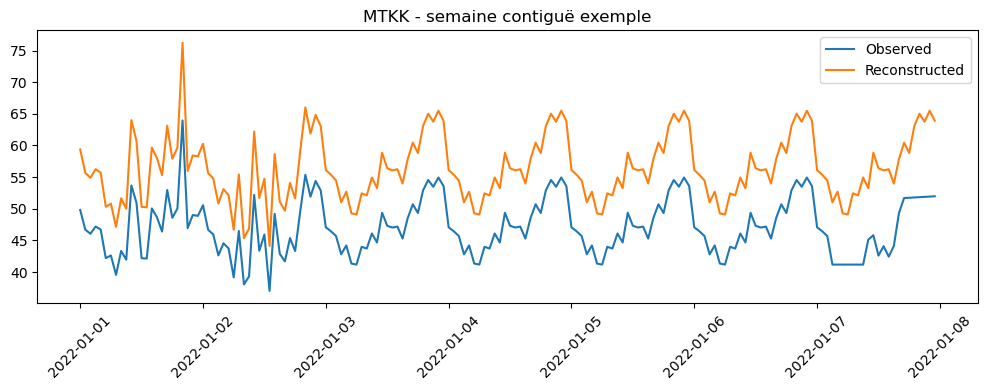

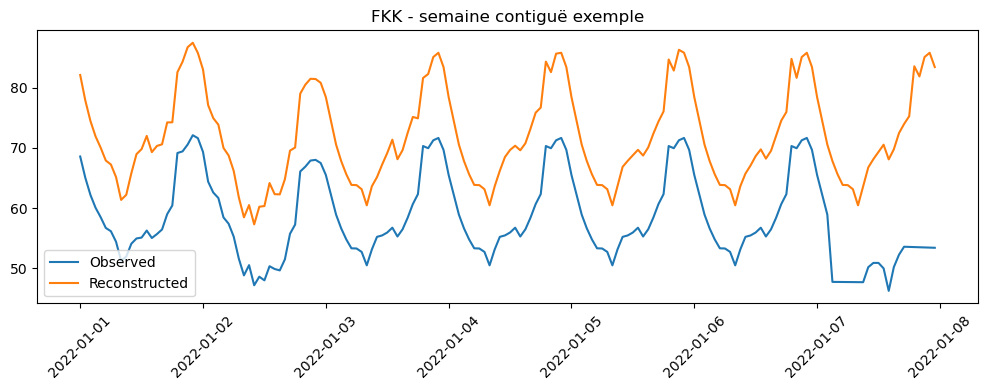

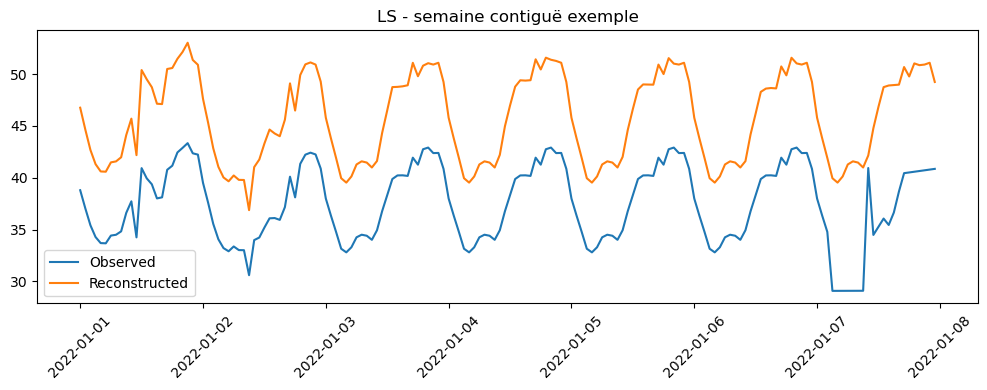

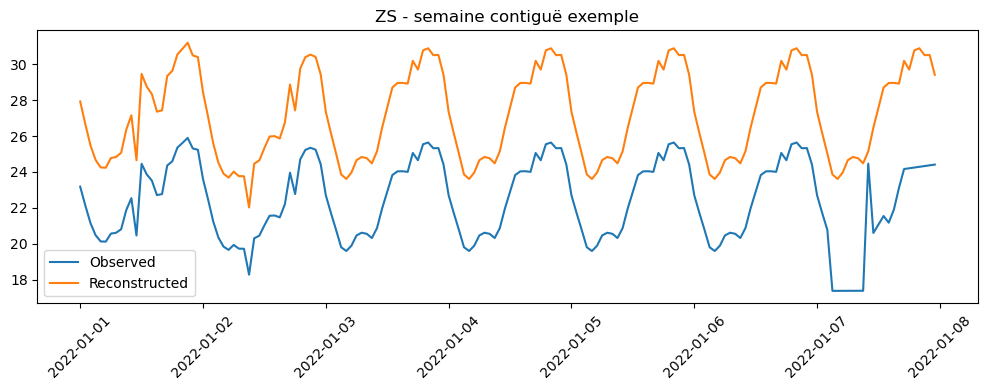

In [35]:
for region in common_regions:
    df_r = validation_df[validation_df["region"] == region].copy()
    sample = first_contiguous_window(df_r, window_hours=24*7)

    if sample is None:
        print(f"Aucune fenêtre contiguë de 7 jours pour {region}")
        continue

    plt.figure()
    plt.plot(sample["datetime"], sample["load_mw"], label="Observed")
    plt.plot(sample["datetime"], sample["load_reconstructed_mw"], label="Reconstructed")
    plt.title(f"{region} - semaine contiguë exemple")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

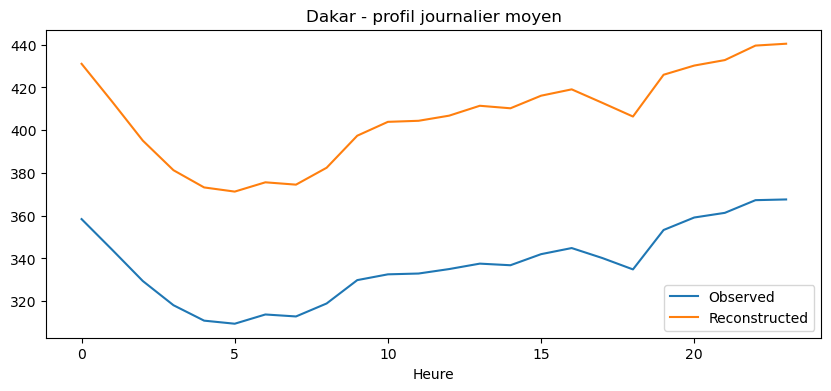

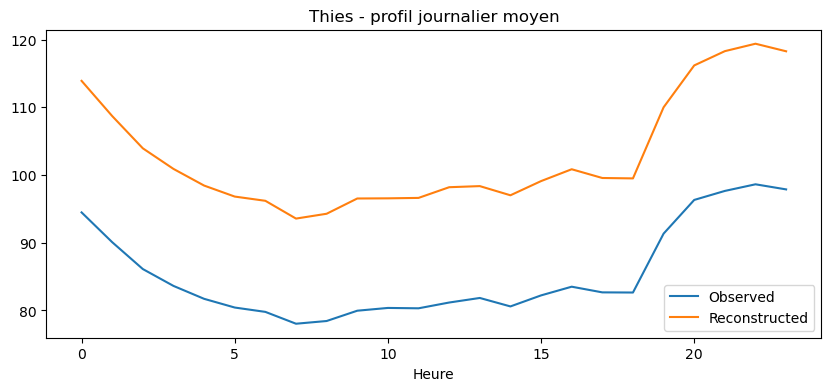

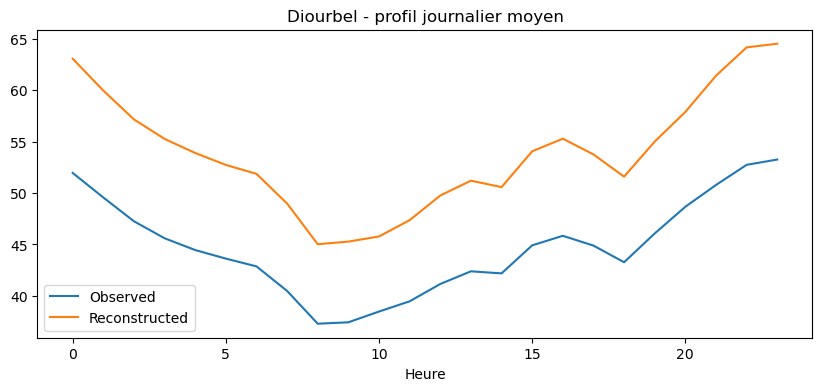

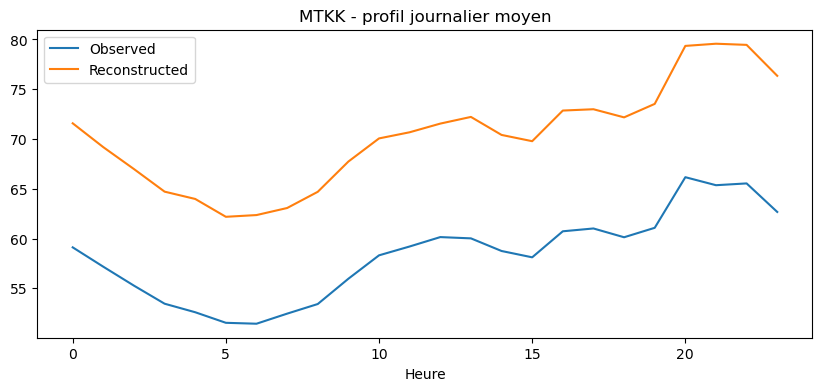

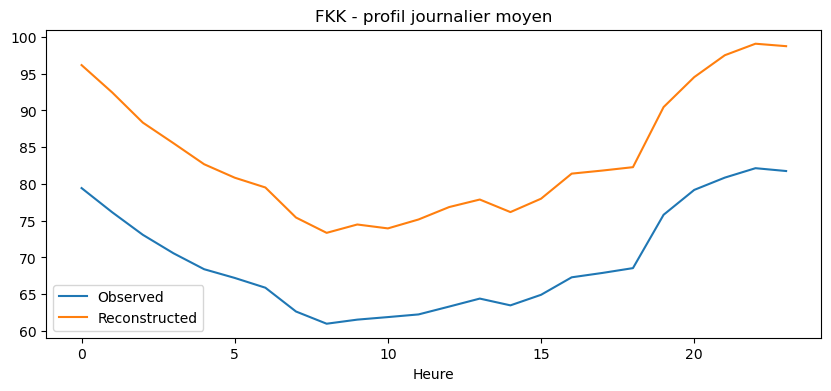

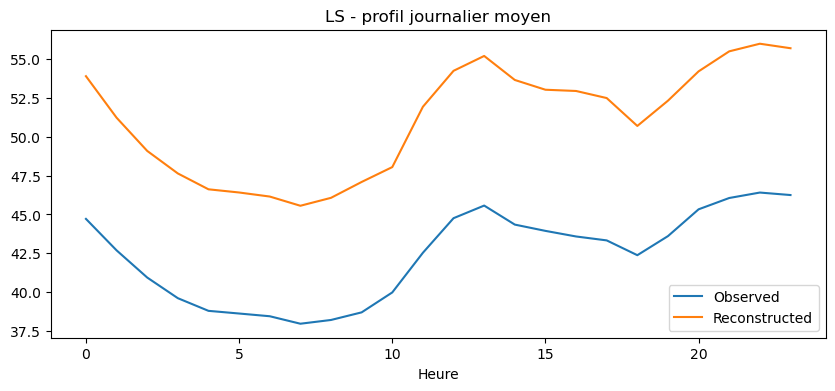

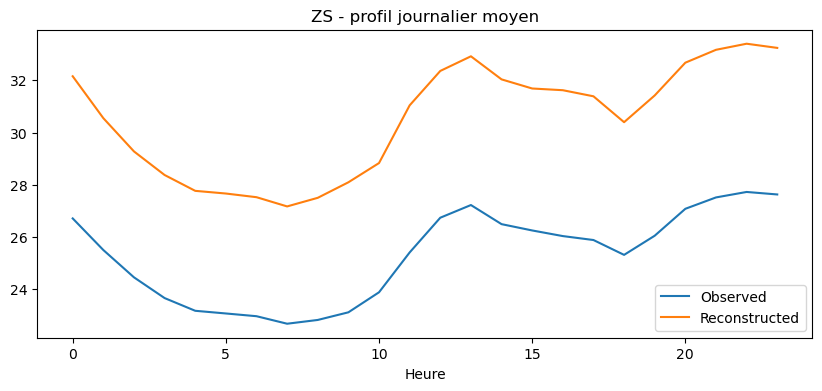

In [36]:
tmp = validation_df.copy()
tmp["hour"] = pd.to_datetime(tmp["datetime"]).dt.hour

for region in common_regions:
    df_r = tmp[tmp["region"] == region]
    if len(df_r) == 0:
        continue

    prof = df_r.groupby("hour", as_index=False)[["load_mw", "load_reconstructed_mw"]].mean()

    plt.figure()
    plt.plot(prof["hour"], prof["load_mw"], label="Observed")
    plt.plot(prof["hour"], prof["load_reconstructed_mw"], label="Reconstructed")
    plt.title(f"{region} - profil journalier moyen")
    plt.xlabel("Heure")
    plt.legend()
    plt.show()

## Exports

In [37]:
beta_df.to_csv(OUT_DIR / "beta_by_region.csv", index=False)
temp_clim.to_csv(OUT_DIR / "temperature_climatology.csv", index=False)
load_ref_class.to_csv(OUT_DIR / "reference_load_profiles.csv", index=False)
regional_shares.to_csv(OUT_DIR / "regional_shares.csv", index=False)
annual_regional.to_csv(OUT_DIR / "regional_annual_energy.csv", index=False)
gap_summary.to_csv(OUT_DIR / "load_observed_gap_summary.csv", index=False)
validation_metrics.to_csv(OUT_DIR / "validation_metrics.csv", index=False)
reconstructed.to_csv(OUT_DIR / "historical_reconstructed_load_2000_2022_long.csv", index=False)

reconstructed_wide = reconstructed.pivot_table(
    index="datetime",
    columns="region",
    values="load_reconstructed_mw"
).sort_index()

reconstructed_wide.to_csv(OUT_DIR / "historical_reconstructed_load_2000_2022_wide.csv")

print("✅ Exports générés dans :", OUT_DIR)

✅ Exports générés dans : /home/ahmany/om4a/genesys-mod/GENeSYS_MOD.tools-main/GIS_&_Timeseries_Tool/out_historical_reconstruction_2000_2022_v2
